In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_excel('/content/Folds5x2_pp.xlsx', sheet_name='Sheet1')

data.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b)(i) Rows and Columns

In [2]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

Number of rows: 9568
Number of columns: 5


There are 9568 rows and 5 columns in the dataset.

Each row represents one hourly observation from the power plant.

The columns represent:
- AT: Ambient Temperature
- V: Exhaust Vacuum
- AP: Ambient Pressure
- RH: Relative Humidity
- PE: Net hourly electrical energy output

AT, V, AP, and RH are the predictors, and PE is the response variable.

### (b)(ii) Pairwise Scatterplots

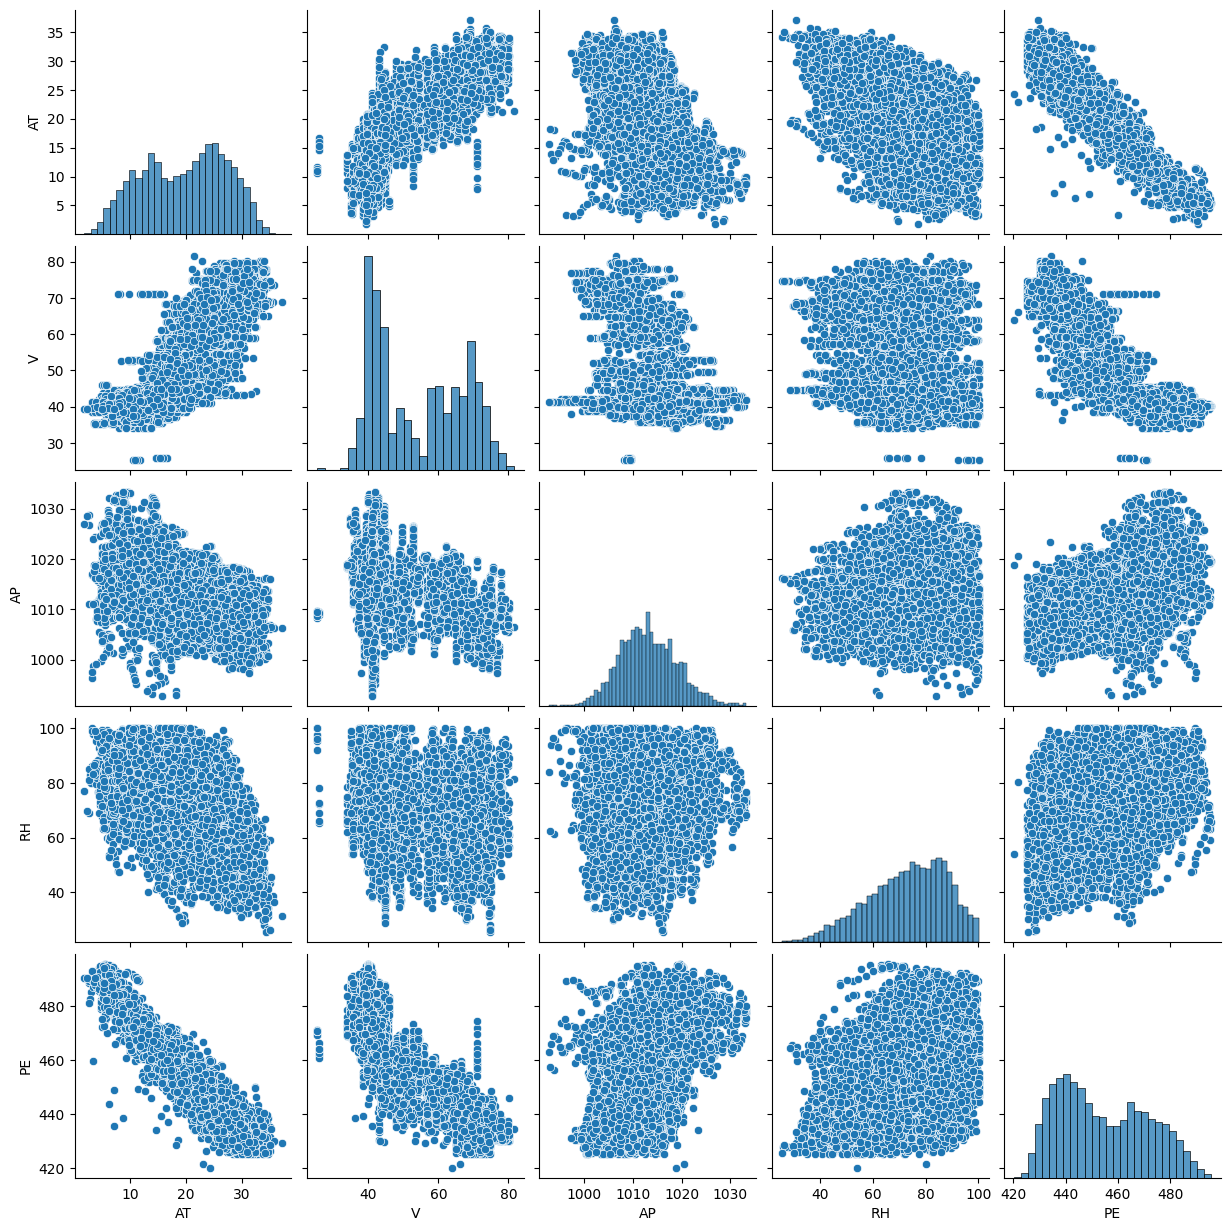

In [3]:
sns.pairplot(data)

plt.show()

AT has a strong negative relationship with PE. As AT increases, PE generally decreases.

V also has a negative relationship with PE, but the relationship is more scattered than AT.

AP has a positive relationship with PE.

RH has a weaker positive relationship with PE.

There are also relationships among the predictors. For example, AT and V have a positive relationship.

### (b)(iii) Summary Statistics

In [4]:
mean = data.mean()
median = data.median()
data_range = data.max() - data.min()
first_quartile = data.quantile(0.25)
third_quartile = data.quantile(0.75)
iqr = third_quartile - first_quartile

summary = pd.DataFrame({
    'Mean': mean,
    'Median': median,
    'Range': data_range,
    'Q1': first_quartile,
    'Q3': third_quartile,
    'IQR': iqr
})

summary

,Mean,Median,Range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

In [5]:
import statsmodels.api as sm

X = data['AT']
y = data['PE']

X = sm.add_constant(X)

model_AT = sm.OLS(y, X).fit()

print(model_AT.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        07:49:04   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   3177.280      0.0

In [6]:
X = data['V']
y = data['PE']

X = sm.add_constant(X)

model_V = sm.OLS(y, X).fit()

print(model_V.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        07:50:37   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.8015      0.378   1370.218      0.0

In [7]:
X = data['AP']
y = data['PE']

X = sm.add_constant(X)

model_AP = sm.OLS(y, X).fit()

print(model_AP.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        07:51:15   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1055.2610     25.459    -41.449      0.0

In [8]:
X = data['RH']
y = data['PE']

X = sm.add_constant(X)

model_RH = sm.OLS(y, X).fit()

print(model_RH.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        07:51:45   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        420.9618      0.823    511.676      0.0

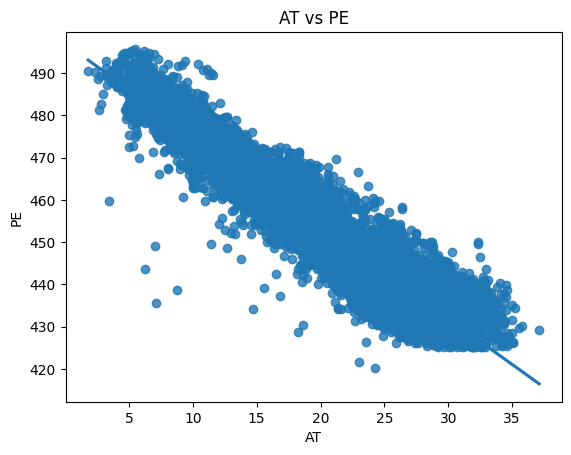

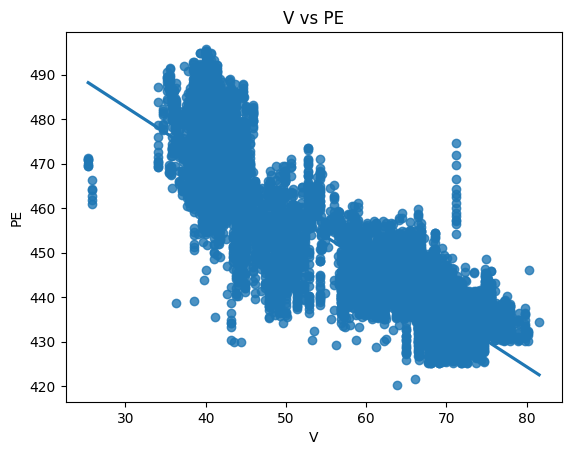

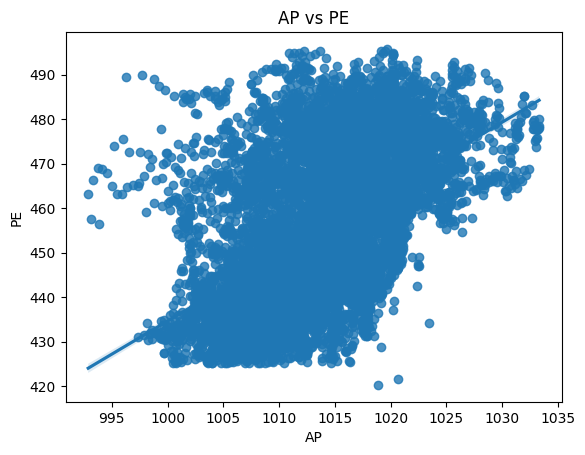

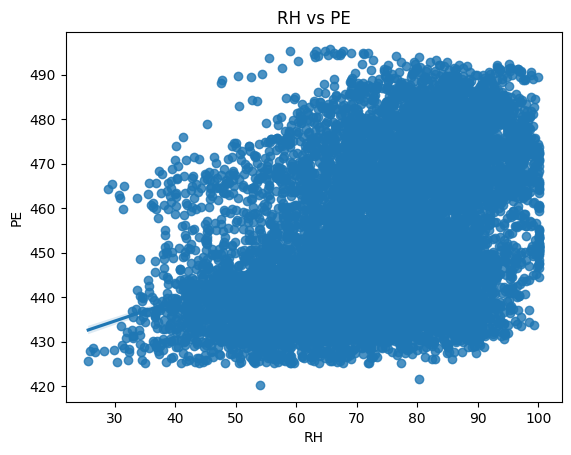

In [9]:
sns.regplot(x='AT', y='PE', data=data)
plt.title('AT vs PE')
plt.show()

sns.regplot(x='V', y='PE', data=data)
plt.title('V vs PE')
plt.show()

sns.regplot(x='AP', y='PE', data=data)
plt.title('AP vs PE')
plt.show()

sns.regplot(x='RH', y='PE', data=data)
plt.title('RH vs PE')
plt.show()

All four predictors have statistically significant associations with PE because their p-values are less than 0.05.

AT and V have negative relationships with PE, while AP and RH have positive relationships with PE. AT has the strongest linear relationship with PE with an R-squared of 0.899, followed by V with an R-squared of 0.757. AP and RH have weaker linear relationships with R-squared values of 0.269 and 0.152.

The regression plots support these results. There are some potential outliers, especially in the AT and V plots. However, I would not remove them based only on the scatterplots because there is not enough evidence that they are incorrect observations.

### (d) Multiple Linear Regression

In [10]:
X = data[['AT', 'V', 'AP', 'RH']]
y = data['PE']

X = sm.add_constant(X)

model_multiple = sm.OLS(y, X).fit()

print(model_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        07:54:18   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

The multiple linear regression model has an R-squared of 0.929.

AT, V, AP, and RH all have p-values less than 0.05. Therefore, I reject the null hypothesis for all four predictors. All four predictors have statistically significant associations with PE in the multiple regression model.

### (e) Compare Simple and Multiple Regression Coefficients

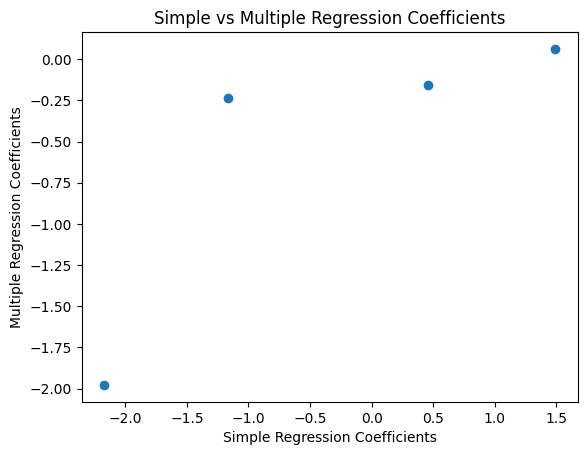

In [11]:
simple_coefficients = [
    model_AT.params['AT'],
    model_V.params['V'],
    model_AP.params['AP'],
    model_RH.params['RH']
]

multiple_coefficients = [
    model_multiple.params['AT'],
    model_multiple.params['V'],
    model_multiple.params['AP'],
    model_multiple.params['RH']
]

plt.scatter(simple_coefficients, multiple_coefficients)

plt.xlabel('Simple Regression Coefficients')
plt.ylabel('Multiple Regression Coefficients')
plt.title('Simple vs Multiple Regression Coefficients')

plt.show()

The coefficients from the simple linear regressions and the multiple linear regression are different.

AT changes only slightly, from about -2.17 to -1.98. V changes from about -1.17 to -0.23, and AP changes from about 1.49 to 0.06. RH changes from a positive coefficient of about 0.46 in the simple regression to a negative coefficient of about -0.16 in the multiple regression.

This happens because the simple regressions consider one predictor at a time, while the multiple regression estimates the effect of each predictor while holding the other predictors constant.

### (f) Nonlinear Association

In [12]:
X = data['AT']

X2 = X ** 2
X3 = X ** 3

X_AT_poly = pd.DataFrame({
    'AT': X,
    'AT2': X2,
    'AT3': X3
})

X_AT_poly = sm.add_constant(X_AT_poly)

model_AT_poly = sm.OLS(data['PE'], X_AT_poly).fit()

print(model_AT_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        07:57:53   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.7281      0.673    732.248      0.0

In [13]:
X = data['V']

X2 = X ** 2
X3 = X ** 3

X_V_poly = pd.DataFrame({
    'V': X,
    'V2': X2,
    'V3': X3
})

X_V_poly = sm.add_constant(X_V_poly)

model_V_poly = sm.OLS(data['PE'], X_V_poly).fit()

print(model_V_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.098e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        07:58:37   Log-Likelihood:                -33585.
No. Observations:                9568   AIC:                         6.718e+04
Df Residuals:                    9564   BIC:                         6.721e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        554.1468      9.151     60.557      0.0

In [27]:
X = data['AP'] - data['AP'].mean()

X2 = X ** 2
X3 = X ** 3

X_AP_poly = pd.DataFrame({
    'AP': X,
    'AP2': X2,
    'AP3': X3
})

X_AP_poly = sm.add_constant(X_AP_poly)

model_AP_poly = sm.OLS(data['PE'], X_AP_poly).fit()

print(model_AP_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     1350.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        08:41:41   Log-Likelihood:                -39032.
No. Observations:                9568   AIC:                         7.807e+04
Df Residuals:                    9564   BIC:                         7.810e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        453.0823      0.180   2520.290      0.0

In [16]:
X = data['RH']

X2 = X ** 2
X3 = X ** 3

X_RH_poly = pd.DataFrame({
    'RH': X,
    'RH2': X2,
    'RH3': X3
})

X_RH_poly = sm.add_constant(X_RH_poly)

model_RH_poly = sm.OLS(data['PE'], X_RH_poly).fit()

print(model_RH_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     579.2
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        08:02:32   Log-Likelihood:                -39923.
No. Observations:                9568   AIC:                         7.985e+04
Df Residuals:                    9564   BIC:                         7.988e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        468.4135     10.545     44.422      0.0

There is evidence of nonlinear association for all four predictors.

For AT, both the quadratic and cubic terms are statistically significant.

For V, the cubic term is statistically significant, while the quadratic term is not significant.

For AP, both the quadratic and cubic terms are statistically significant.

For RH, both the quadratic and cubic terms are statistically significant.

### (g) Interaction Terms

In [17]:
X_interaction = pd.DataFrame({
    'AT': data['AT'],
    'V': data['V'],
    'AP': data['AP'],
    'RH': data['RH'],
    'AT_V': data['AT'] * data['V'],
    'AT_AP': data['AT'] * data['AP'],
    'AT_RH': data['AT'] * data['RH'],
    'V_AP': data['V'] * data['AP'],
    'V_RH': data['V'] * data['RH'],
    'AP_RH': data['AP'] * data['RH']
})

X_interaction = sm.add_constant(X_interaction)

model_interaction = sm.OLS(data['PE'], X_interaction).fit()

print(model_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        08:03:34   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        685.7825     78.640      8.721      0.0

The statistically significant interaction terms are AT × V, AT × RH, V × AP, and AP × RH because their p-values are less than 0.05.

The interaction terms AT × AP and V × RH are not statistically significant because their p-values are greater than 0.05.

### (h) Model Improvement

In [18]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    data,
    test_size=0.30,
    random_state=1
)

print("Training set:", train_data.shape)
print("Test set:", test_data.shape)

Training set: (6697, 5)
Test set: (2871, 5)


In [19]:
from sklearn.metrics import mean_squared_error

X_train = train_data[['AT', 'V', 'AP', 'RH']]
y_train = train_data['PE']

X_test = test_data[['AT', 'V', 'AP', 'RH']]
y_test = test_data['PE']

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

model_basic = sm.OLS(y_train, X_train).fit()

train_prediction = model_basic.predict(X_train)
test_prediction = model_basic.predict(X_test)

train_mse = mean_squared_error(y_train, train_prediction)
test_mse = mean_squared_error(y_test, test_prediction)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

Train MSE: 20.766119761450938
Test MSE: 20.777478106883994


In [20]:
X_train_full = pd.DataFrame({
    'AT': train_data['AT'],
    'V': train_data['V'],
    'AP': train_data['AP'],
    'RH': train_data['RH'],
    'AT2': train_data['AT'] ** 2,
    'V2': train_data['V'] ** 2,
    'AP2': train_data['AP'] ** 2,
    'RH2': train_data['RH'] ** 2,
    'AT_V': train_data['AT'] * train_data['V'],
    'AT_AP': train_data['AT'] * train_data['AP'],
    'AT_RH': train_data['AT'] * train_data['RH'],
    'V_AP': train_data['V'] * train_data['AP'],
    'V_RH': train_data['V'] * train_data['RH'],
    'AP_RH': train_data['AP'] * train_data['RH']
})

X_train_full = sm.add_constant(X_train_full)

model_full = sm.OLS(y_train, X_train_full).fit()

print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7181.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        08:08:14   Log-Likelihood:                -19192.
No. Observations:                6697   AIC:                         3.841e+04
Df Residuals:                    6682   BIC:                         3.852e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8171.8080   1416.708     -5.768      0.0

In [21]:
X_train_reduced = pd.DataFrame({
    'AT': train_data['AT'],
    'V': train_data['V'],
    'AP': train_data['AP'],
    'RH': train_data['RH'],
    'AT2': train_data['AT'] ** 2,
    'AP2': train_data['AP'] ** 2,
    'RH2': train_data['RH'] ** 2,
    'AT_V': train_data['AT'] * train_data['V'],
    'AT_RH': train_data['AT'] * train_data['RH'],
    'AP_RH': train_data['AP'] * train_data['RH']
})

X_train_reduced = sm.add_constant(X_train_reduced)

model_reduced = sm.OLS(y_train, X_train_reduced).fit()

print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                 1.004e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        08:09:14   Log-Likelihood:                -19198.
No. Observations:                6697   AIC:                         3.842e+04
Df Residuals:                    6686   BIC:                         3.849e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.052e+04   1079.936     -9.738      0.0

In [22]:
X_test_reduced = pd.DataFrame({
    'AT': test_data['AT'],
    'V': test_data['V'],
    'AP': test_data['AP'],
    'RH': test_data['RH'],
    'AT2': test_data['AT'] ** 2,
    'AP2': test_data['AP'] ** 2,
    'RH2': test_data['RH'] ** 2,
    'AT_V': test_data['AT'] * test_data['V'],
    'AT_RH': test_data['AT'] * test_data['RH'],
    'AP_RH': test_data['AP'] * test_data['RH']
})

X_test_reduced = sm.add_constant(X_test_reduced)

train_prediction_reduced = model_reduced.predict(X_train_reduced)
test_prediction_reduced = model_reduced.predict(X_test_reduced)

train_mse_reduced = mean_squared_error(y_train, train_prediction_reduced)
test_mse_reduced = mean_squared_error(y_test, test_prediction_reduced)

print("Reduced Model Train MSE:", train_mse_reduced)
print("Reduced Model Test MSE:", test_mse_reduced)

Reduced Model Train MSE: 18.093235651112387
Reduced Model Test MSE: 18.263588112309115


The basic multiple regression model has a training MSE of 20.7661 and a test MSE of 20.7775.

The reduced model with significant quadratic and interaction terms has a training MSE of 18.0932 and a test MSE of 18.2636.

Therefore, the reduced nonlinear and interaction model performs better because it has lower training and test MSEs.

### (i) KNN Regression

In [23]:
from sklearn.neighbors import KNeighborsRegressor

X_train_knn = train_data[['AT', 'V', 'AP', 'RH']]
y_train_knn = train_data['PE']

X_test_knn = test_data[['AT', 'V', 'AP', 'RH']]
y_test_knn = test_data['PE']

k_values = list(range(1, 101))

train_errors = []
test_errors = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_train_knn, y_train_knn)

    train_prediction = knn.predict(X_train_knn)
    test_prediction = knn.predict(X_test_knn)

    train_error = mean_squared_error(y_train_knn, train_prediction)
    test_error = mean_squared_error(y_test_knn, test_prediction)

    train_errors.append(train_error)
    test_errors.append(test_error)

best_error = min(test_errors)
best_index = test_errors.index(best_error)
best_k_raw = k_values[best_index]

print("Best k for raw features:", best_k_raw)
print("Best test MSE:", best_error)

Best k for raw features: 5
Best test MSE: 15.704821203761764


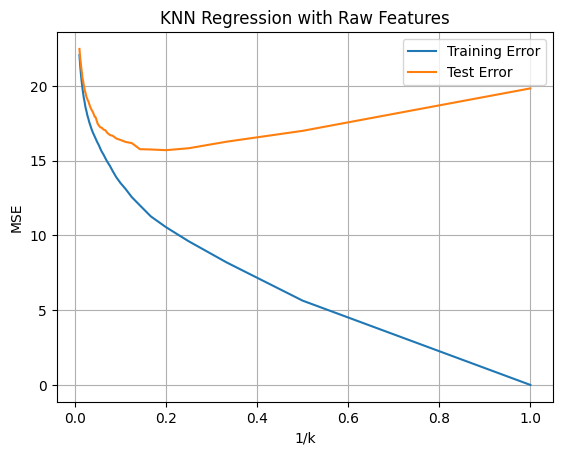

In [24]:
inverse_k = []

for k in k_values:
    inverse_k.append(1 / k)

plt.plot(inverse_k, train_errors, label='Training Error')
plt.plot(inverse_k, test_errors, label='Test Error')

plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN Regression with Raw Features')
plt.legend()
plt.grid()
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_normalized = scaler.fit_transform(X_train_knn)
X_test_normalized = scaler.transform(X_test_knn)

train_errors_normalized = []
test_errors_normalized = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_train_normalized, y_train_knn)

    train_prediction = knn.predict(X_train_normalized)
    test_prediction = knn.predict(X_test_normalized)

    train_error = mean_squared_error(y_train_knn, train_prediction)
    test_error = mean_squared_error(y_test_knn, test_prediction)

    train_errors_normalized.append(train_error)
    test_errors_normalized.append(test_error)

best_error_normalized = min(test_errors_normalized)
best_index = test_errors_normalized.index(best_error_normalized)
best_k_normalized = k_values[best_index]

print("Best k for normalized features:", best_k_normalized)
print("Best test MSE:", best_error_normalized)

Best k for normalized features: 4
Best test MSE: 14.070606067136888


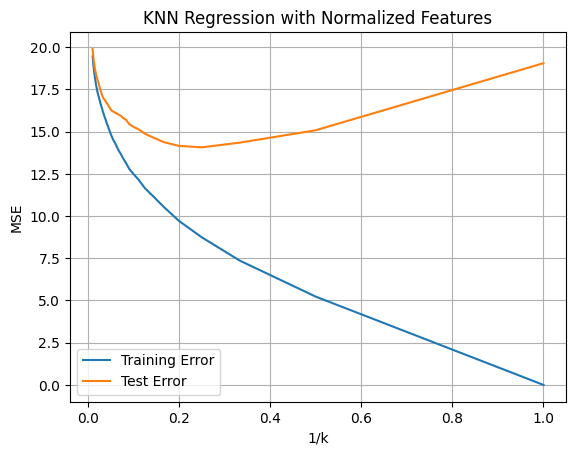

In [26]:
plt.plot(inverse_k, train_errors_normalized, label='Training Error')
plt.plot(inverse_k, test_errors_normalized, label='Test Error')

plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN Regression with Normalized Features')
plt.legend()
plt.grid()
plt.show()

### (j) Comparison

The reduced linear regression model has a test MSE of 18.2636.

The KNN regression model with raw features has a test MSE of 15.7048, and the KNN regression model with normalized features has a test MSE of 14.0706.

Therefore, the KNN regression model with normalized features performs the best because it has the lowest test MSE. Normalizing the features improves the KNN model because KNN is based on distances between observations.

### 2. ISLR 2.4.1

(a) Better. Since the sample size is extremely large and the number of predictors is small, a flexible method has enough observations to fit the relationship without a high risk of overfitting.

(b) Worse. Since the number of predictors is extremely large and the number of observations is small, a flexible method is more likely to overfit the data.

(c) Better. Since the relationship between the predictors and the response is highly non-linear, a flexible method can capture the relationship better than an inflexible method.

(d) Worse. Since the variance of the error terms is extremely high, a flexible method is more likely to fit the noise in the data and overfit.

### 3. ISLR 2.4.7

(a)

The Euclidean distance is

d = sqrt((X1 - 0)^2 + (X2 - 0)^2 + (X3 - 0)^2)

The distances are:

1. Observation 1: sqrt(0^2 + 3^2 + 0^2) = 3
2. Observation 2: sqrt(2^2 + 0^2 + 0^2) = 2
3. Observation 3: sqrt(0^2 + 1^2 + 3^2) = sqrt(10) ≈ 3.162
4. Observation 4: sqrt(0^2 + 1^2 + 2^2) = sqrt(5) ≈ 2.236
5. Observation 5: sqrt((-1)^2 + 0^2 + 1^2) = sqrt(2) ≈ 1.414
6. Observation 6: sqrt(1^2 + 1^2 + 1^2) = sqrt(3) ≈ 1.732

(b)

For K = 1, the prediction is Green.

Observation 5 is the closest observation to the test point, and its response is Green.

(c)

For K = 3, the three nearest observations are:

- Observation 5: Green
- Observation 6: Red
- Observation 2: Red

Since two of the three nearest neighbors are Red, the prediction is Red.

(d)

If the Bayes decision boundary is highly non-linear, a small value of K would generally be better.

A small K gives a more flexible decision boundary and can better capture a complicated non-linear relationship. A large K produces a smoother and less flexible decision boundary.